In [40]:
import skimage
from skimage.util import img_as_float, img_as_ubyte
import cv2
from skimage import color, io
from matplotlib import pyplot as plt
import numpy as np
from skimage.filters import threshold_otsu
from skimage.color import rgb2hsv

In [3]:
data_pth = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex3-PixelwiseOperations/data/"

In [9]:
img = io.imread(data_pth + "vertebra.png")

In [11]:
# Lx-3.1 Convert from unsigned byte to float images 
print("Original image data type:", img.dtype)
img = img_as_float(img)
print("Converted image data type:", img.dtype)


Original image data type: uint8
Converted image data type: float64


In [12]:
# Lx-3.2 Convert from float to unsigned byte images
img = img_as_ubyte(img)
print("Converted back to unsigned byte data type:", img.dtype)

Converted back to unsigned byte data type: uint8


(998, 800)
Minimum pixel value: 57
Maximum pixel value: 235
Stretched image data type: float64
Stretched image min value: 0.0
Stretched image max value: 255.0


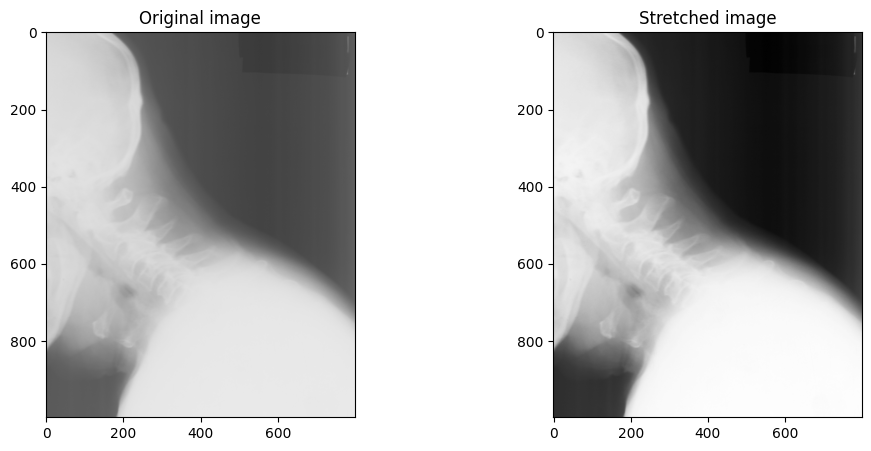

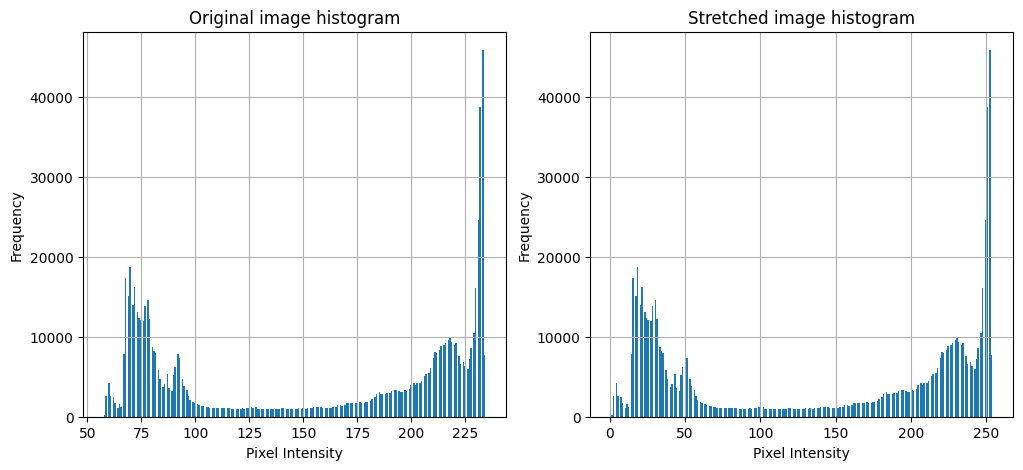

In [ ]:
# Lx-3.3 Implement a function that can do linear histogram stretching of a gray level image
print(img.shape)
pixel_min = img.min()
pixel_max = img.max()
print("Minimum pixel value:", pixel_min)
print("Maximum pixel value:", pixel_max)

def histogram_stretch(img,v_min,v_max,v_min_des,v_max_des):
    stretched_img = (v_max_des - v_min_des)/(v_max - v_min) * (img - v_min) + v_min_des



    return stretched_img



histogram_stretched_img = histogram_stretch(img, pixel_min, pixel_max, 0, 255)
print("Stretched image data type:", histogram_stretched_img.dtype)
print("Stretched image min value:", histogram_stretched_img.min())
print("Stretched image max value:", histogram_stretched_img.max())




fig, ax = plt.subplots(nrows=1, ncols = 2, figsize = (12, 5))
ax[0].imshow(img, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original image')
ax[1].imshow(histogram_stretched_img, cmap = 'gray', vmin = 0, vmax = 255)
ax[1].set_title('Stretched image')
plt.show()


fig, ax = plt.subplots(nrows=1, ncols = 2, figsize = (12, 5))
ax[0].hist(img.ravel(), bins=256)
ax[0].set_title("Original image histogram")
ax[0].set_xlabel("Pixel Intensity")
ax[0].set_ylabel("Frequency")
ax[0].grid()
ax[1].hist(histogram_stretched_img.ravel(), bins=256)
ax[1].set_title("Stretched image histogram")
ax[1].set_xlabel("Pixel Intensity")
ax[1].set_ylabel("Frequency")
ax[1].grid()
plt.show()




Converting image to float for gamma mapping.
Gamma mapped image data type: float64


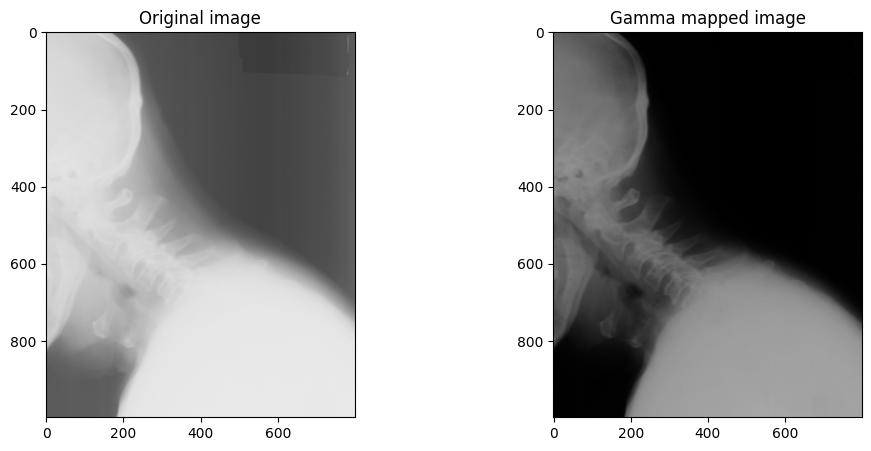

In [28]:
# Lx-3.3 Implement a function that can do gamma mapping of a grey level image



def gamma_map(img, gamma):
    if img.dtype != np.float64:
        print("Converting image to float for gamma mapping.")
        img = img_as_float(img)
    gamma_mapped_img = np.power(img, gamma)
    print("Gamma mapped image data type:", gamma_mapped_img.dtype)
    return img_as_ubyte(gamma_mapped_img)



gamma_val = 5
gamma_mapped_img = gamma_map(img, gamma_val)


fig, ax = plt.subplots(nrows=1, ncols = 2, figsize = (12, 5))
ax[0].imshow(img, cmap = 'gray', vmin = 0, vmax = 255)
ax[0].set_title('Original image')
ax[1].imshow(gamma_mapped_img, cmap = 'gray', vmin = 0, vmax = 255)
ax[1].set_title('Gamma mapped image')
plt.show()

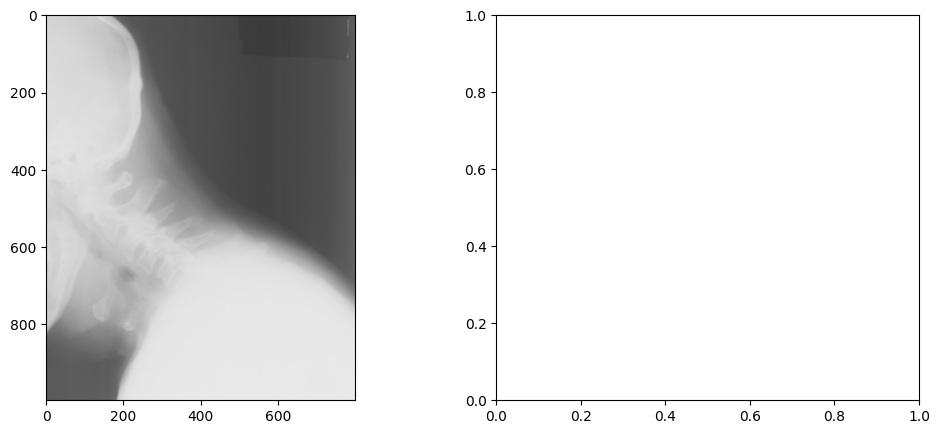

In [36]:
# Lx-3.5: Manually threshold a gray scale image 

def manual_threshold(img, threshold):
    return img_as_ubyte(img > threshold)

threshold_val = 148
thresholded_img = manual_threshold(img, threshold_val)
fig, ax = plt.subplots(nrows=1, ncols = 2, figsize = (12, 5))
ax[0].imshow(img, cmap = 'gray', vmin = 0, vmax
= 255)

In [ ]:
# Lx-3.6 Otsu automatic thresholding
threshold_otsu_val = threshold_otsu(img)
print("Otsu threshold value:", threshold_otsu_val)



Otsu threshold value: 148
Otsu threshold value with parameters: 414437


In [38]:
# Lx-3.7 Perform RGB Thresholding in a color image

img = io.imread(data_pth + "DTUSigns2.jpg")
R_channel = img[:,:,0]
G_channel = img[:,:,1]
B_channel = img[:,:,2]

otsu_R = threshold_otsu(R_channel)
otsu_G = threshold_otsu(G_channel)
otsu_B = threshold_otsu(B_channel)

print("Otsu threshold for R channel:", otsu_R)
print("Otsu threshold for G channel:", otsu_G)
print("Otsu threshold for B channel:", otsu_B)

Otsu threshold for R channel: 114
Otsu threshold for G channel: 118
Otsu threshold for B channel: 103


HSV image shape: (3024, 4032, 3)
HSV image data type: float64


/tmp/ipykernel_194597/2575000127.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_hsv)
/tmp/ipykernel_194597/2575000127.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


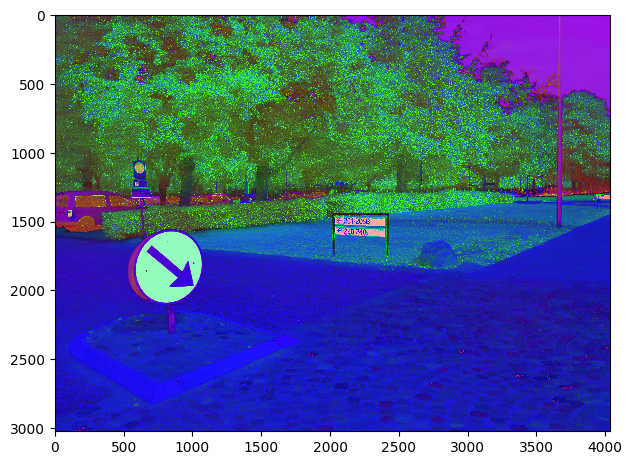

In [41]:
# Lx-3.8 Convert a RGB image to HSV
img_hsv = rgb2hsv(img)
print("HSV image shape:", img_hsv.shape)
print("HSV image data type:", img_hsv.dtype)
io.imshow(img_hsv)
io.show()


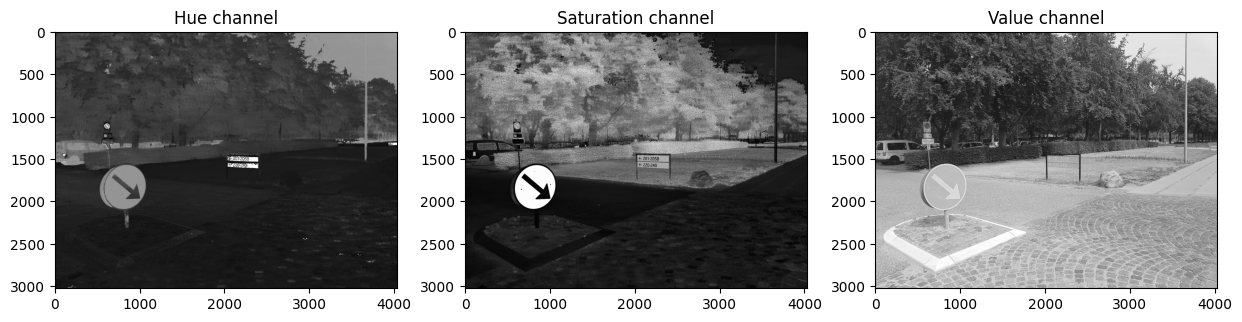

In [42]:
# Lx-3.9 Visualize invidivual channels of a HSV image

H = img_hsv[:,:,0]
S = img_hsv[:,:,1]
V = img_hsv[:,:,2]

fig, ax = plt.subplots(nrows=1, ncols = 3, figsize = (15, 5))
ax[0].imshow(H, cmap = 'gray')
ax[0].set_title('Hue channel')
ax[1].imshow(S, cmap = 'gray')
ax[1].set_title('Saturation channel')
ax[2].imshow(V, cmap = 'gray')
ax[2].set_title('Value channel')
plt.show()


In [ ]:
# Lx-3.10 Implement and test thresholding in HSV Space